Importamos en primer lugar algunos componentes útiles de *scikit-learn*, incluyendo una versión del **Conjunto de datos de viviendas de California**

In [1]:
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [2]:
housing = fetch_california_housing(as_frame=True)

In [3]:
housing.frame.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


Particionar los datos en **entrenamiento + prueba** y luego dividir aún más los datos de entrenamiento en **entrenamiento + validación**

In [4]:
X_train_full, X_test, y_train_full, y_test = train_test_split(
    housing.data, housing.target)
X_train, X_valid, y_train, y_valid = train_test_split(
    X_train_full, y_train_full)

Escalar los atributos de entrada usando **StardardScaler**

In [5]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_valid = scaler.transform(X_valid)
X_test = scaler.transform(X_test)

Construir la arquitectura de una red neuronal usando Keras y Tensorflow

In [6]:
import tensorflow as tf
from tensorflow import keras

In [7]:
model = keras.models.Sequential()

model.add(keras.layers.Input(shape=X_train.shape[1:]))
# Add the first layer: an input layer with all the data attributes except the first one

model.add(keras.layers.Dense(30, activation="relu"))
# Add a dense hidden layer with 30 neurons and ReLU activation function

model.add(keras.layers.Dense(1))
# Dense output layer, with one neuron (single-target regression) and no activation function

Este es un conjunto de datos ruidoso y, en tal caso, es mejor comenzar a probar una arquitectura ANN más simple, con solo una capa oculta y 30 neuronas en ella, para evitar un posible **sobreajuste**.

In [8]:
from keras import optimizers

optimizer = optimizers.Adam(clipvalue=0.5)

model.compile(loss="mean_squared_error", optimizer=optimizer)
history = model.fit(X_train, y_train, epochs=20,
                    validation_data=(X_valid, y_valid))

Epoch 1/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - loss: 2.2687 - val_loss: 0.6654
Epoch 2/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.6586 - val_loss: 0.4961
Epoch 3/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.5292 - val_loss: 0.4296
Epoch 4/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.4763 - val_loss: 0.4025
Epoch 5/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.4432 - val_loss: 0.3888
Epoch 6/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.4233 - val_loss: 0.3784
Epoch 7/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.4083 - val_loss: 0.3717
Epoch 8/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.4014 - val_loss: 0.3659
Epoch 9/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3973 - val_loss: 0.3589
Epoch 10/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3894 - val_loss: 0.3602
Epoch 11/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3846 - val_loss: 0.3604
Epoch 12/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step

In [9]:
mse_test = model.evaluate(X_test, y_test)
mse_test

162/162 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3621


0.36205899715423584

In [10]:
X_new = X_test[:3]
y_pred = model.predict(X_new)
y_pred

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 206ms/step


array([[2.4267628],
       [0.9166789],
       [0.893692 ]], dtype=float32)

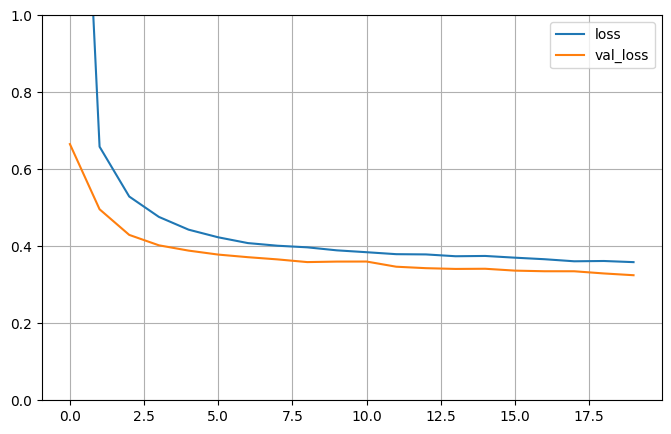

In [11]:
import pandas as pd
import matplotlib.pyplot as plt

pd.DataFrame(history.history).plot(figsize=(8,5))
plt.grid(True)
plt.gca().set_ylim(0,1) #Show the [0-1] range for the y axis
plt.show()